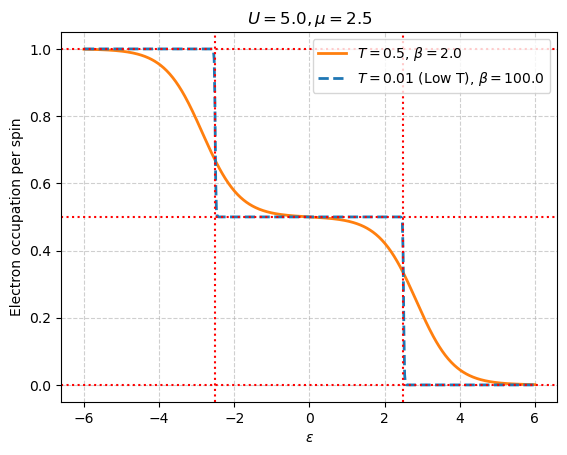

124


In [ ]:
#electron occupation per spin of HK model
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
import time

U = 5.0
mu = U/2.0
T1 = 0.5
T2 = 0.01
#beta1 = 1.0/T1
#beta2 = 1.0/T2

epsilon_list = np.linspace(-6.0, 6.0, 600)

def occupation_per_spin(epsilon, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_minus_mu
    E_2 = -beta*(2*epsilon_minus_mu+U)
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + 2.0*np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

n_T1 = occupation_per_spin(epsilon_list, mu=mu, U=U, T=T1)
n_T2 = occupation_per_spin(epsilon_list, mu=mu, U=U, T=T2)

plt.plot(epsilon_list, n_T1, label=f'$T={T1}$, $\\beta={1/T1:.1f}$', linewidth=2, color='C1')
plt.plot(epsilon_list, n_T2, '--', label=f'$T={T2}$ (Low T), $\\beta={1/T2:.1f}$', linewidth=2, color='C0')

E_single = mu
E_double = mu - U

plt.axvline(E_single, color='red', linestyle=':')
plt.axvline(E_double, color='red', linestyle=':')

plt.axhline(1.0, color='red', linestyle=':')
plt.axhline(0.5, color='red', linestyle=':')
plt.axhline(0.0, color='red', linestyle=':')

plt.title(fr'$U={U}, \mu={mu}$')
plt.xlabel('$\\varepsilon$')
plt.ylabel('Electron occupation per spin')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(-0.05, 1.05)
plt.savefig('HK_n.png')
plt.show()

mu = -3.5 low Tc
mu = -3.2586206896551726 low Tc
mu = -3.0172413793103448 low Tc
mu = -2.7758620689655173 low Tc
mu = -2.293103448275862 low Tc
mu = 1.8103448275862073 low Tc
mu = 2.775862068965518 low Tc
mu = 3.017241379310345 low Tc
mu = 3.5 low Tc


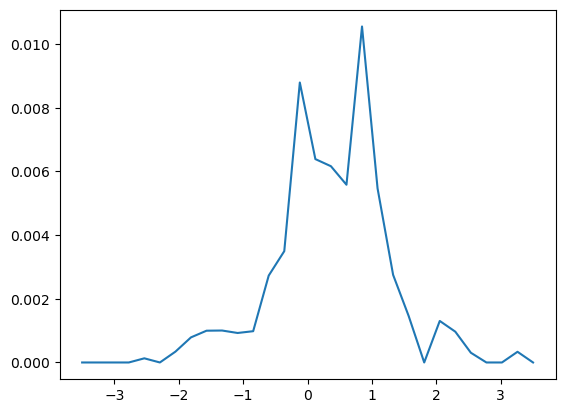

In [ ]:
#HK model Tc vs chemical potential mu (Nat. Phys. 16, 1175–1180 (2020))
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time

kB = 1.0
t = 1.0
d = 2.0    #spatial dimension
W = 4*d*t  #band width
g = 0.1*W  #pair coupling

U = 0.1*W

Nk = 128
kx_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
ky_list = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

def band(kx, ky):
    return -2.0*(np.cos(kx) + np.cos(ky))

def occupation_per_spin(epsilon, mu, U, T):
    epsilon_minus_mu = epsilon - mu
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    E_1 = -beta*epsilon_minus_mu
    E_2 = -beta*(2*epsilon_minus_mu+U)
    E_0 = np.full_like(E_1, 0)
    E_max = np.maximum.reduce([E_0, E_1, E_2])
    numerator = np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    denominator = np.exp(E_0 - E_max) + 2.0*np.exp(E_1 - E_max) + np.exp(E_2 - E_max)
    return numerator/denominator

def chi0_hk(T, mu, U):
    if T < 1e-8:
        T = 1e-8
    beta = 1.0/T
    epsilon = band(KX, KY)
    n_k = occupation_per_spin(epsilon, mu, U, T)
    epsilon_minus_mu = epsilon - mu
    
    term_1_denominator = 2.0*epsilon_minus_mu
    term_1_numerator = (1.0 - n_k)**2*np.tanh(beta*epsilon_minus_mu/2.0)
    term_1 = np.where(np.abs(epsilon_minus_mu) < 1e-6, 
                      (1.0 - n_k)**2*beta/4.0,
                     term_1_numerator/term_1_denominator)
    epsilon_plus_U = epsilon_minus_mu + U
    term_2_denominator = 2.0*epsilon_plus_U
    term_2_numerator = n_k**2*np.tanh(beta*epsilon_plus_U/2.0)
    term_2 = np.where(np.abs(epsilon_plus_U) < 1e-6, 
                      n_k**2*beta/4.0,
                     term_2_numerator/term_2_denominator)
    
    chi0 = np.sum(term_1 + term_2)/N
    return chi0

def tc_equation(T, mu, U, g):
    return g*chi0_hk(T, mu, U) - 1.0

def find_Tc(mu, U, g):
    T_max = 1.0
    T_min = 1e-7
    if tc_equation(T_max, mu, U, g) > 0:
        T_high = T_max
        while tc_equation(T_high, mu, U, g) > 0 and T_high < 10.0:
            T_high *= 2
        T_max = T_high
        print('T_high=', T_max)
        
    if tc_equation(T_min, mu, U, g) < 0:
        print('mu =', mu, 'low Tc')
        return 0.0
         
    try:
        Tc = brentq(tc_equation, T_min, T_max, args=(mu, U, g))
        return Tc
    except ValueError:
        return 0.0
    return Tc

mu_list = np.linspace(-3.5, 3.5, 30)
Tc_result = [find_Tc(mu, U, g) for mu in mu_list]

plt.plot(mu_list, Tc_result)

dopping_x = -0.04056230826443841 Tc = 0.0057876618143673855
dopping_x = -0.03296314153196045 Tc = 0.0057299448992448624
dopping_x = -0.02538522789848341 Tc = 0.0056856053156919195
dopping_x = -0.017823250316422845 Tc = 0.005654470964100032
dopping_x = -0.010271324719363317 Tc = 0.005635855510526659
dopping_x = -0.002724809865523259 Tc = 0.005629300501232208
dopping_x = 0.004821325247641672 Tc = 0.0056351352004230205
dopping_x = 0.012372690161272182 Tc = 0.005653243518695655
dopping_x = 0.019933819899822125 Tc = 0.005683656911134994
dopping_x = 0.027510171783220128 Tc = 0.005727270486948113
dopping_x = 0.03510762248012422 Tc = 0.005784507354888679
dopping_x = 0.042731508360966064 Tc = 0.005856006948325221
dopping_x = 0.0503884238418546 Tc = 0.005943463945798465
dopping_x = 0.05808540391687578 Tc = 0.006048038861898683
dopping_x = 0.06582984707158024 Tc = 0.006171517693598636
dopping_x = 0.07363075792443352 Tc = 0.006316884357051677
dopping_x = 0.08149825282567824 Tc = 0.0064869399408112

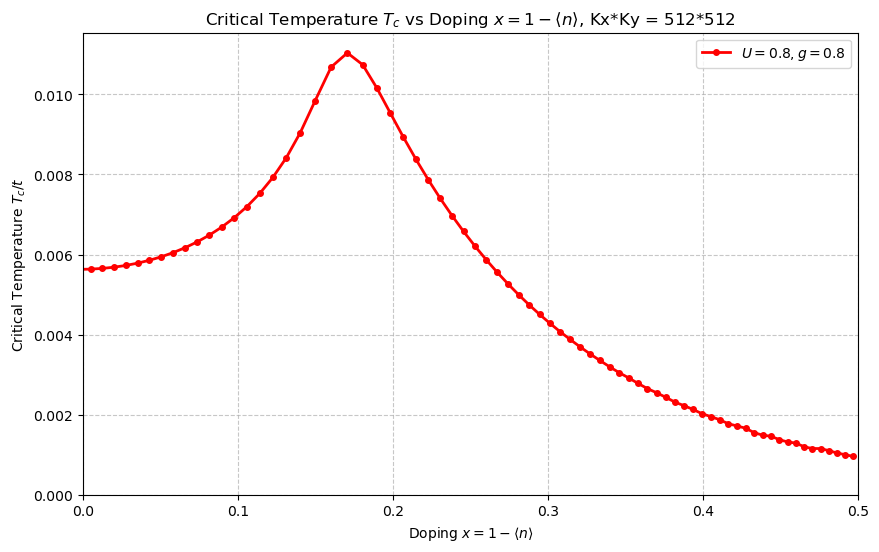

In [3]:
#HK model Tc vs dopoing (Nat. Phys. 16, 1175–1180 (2020))
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time

kB = 1.0
t = 1.0
d = 2.0    #spatial dimension
W = 4*d*t  #band width
g = 0.1*W  #pair coupling

U = 0.1*W
#U = 0.4*W
#U = 0.6*W

Nk = 256 *2
kx_list = np.linspace(0, np.pi, Nk, endpoint=False)
ky_list = np.linspace(0, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    n_k = occupation_per_spin(epsilon, mu, U, T)
    return 2.0*np.sum(n_k) / N

mu_list = np.linspace(0.5, -1.5, 100)  #U=0.1*W
#mu_list = np.linspace(1.7, -0.5, 110)  #U=0.1*W
#mu_list = np.linspace(2.5, -0.5, 110)  #U=0.1*W

Tc_results = []
Doping_x_results = []

start_time = time.time()
for mu in mu_list:
    Tc = find_Tc(mu, U, g)
    T_threshold = 1e-6
    if Tc > T_threshold:
        avg_n = average_occupation(mu, Tc, U, KX, KY, N)
        doping_x = 1.0 - avg_n
    else:
        avg_n = average_occupation(mu, T_threshold, U, KX, KY, N)
        doping_x = 1.0 - avg_n
    print('dopping_x =', doping_x, 'Tc =', Tc)
    Tc_results.append(Tc)
    Doping_x_results.append(doping_x)

x_plot = np.array(Doping_x_results)
Tc_plot = np.array(Tc_results)

mask_lower = x_plot >= -0.01
mask_upper = x_plot < 0.5
mask_combined = mask_lower & mask_upper

Tc_final = Tc_plot[mask_combined]
x_final = x_plot[mask_combined]

sort_indices = np.argsort(x_final)
x_final = x_final[sort_indices]
Tc_final = Tc_final[sort_indices]

end_time = time.time()
print(end_time-start_time)

plt.figure(figsize=(10, 6))
plt.plot(x_final, Tc_final, 'ro-', linewidth=2, markersize=4, label=f'$U={U}, g={g}$')
plt.title(f'Critical Temperature $T_c$ vs Doping $x = 1 - \\langle n \\rangle$, Kx*Ky = {Nk}*{Nk}')
plt.xlabel('Doping $x = 1 - \\langle n \\rangle$')
plt.ylabel('Critical Temperature $T_c / t$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.5) # 通常只显示 x=0 到 x=0.5 区域
plt.ylim(bottom=0)
plt.legend()
plt.show() 

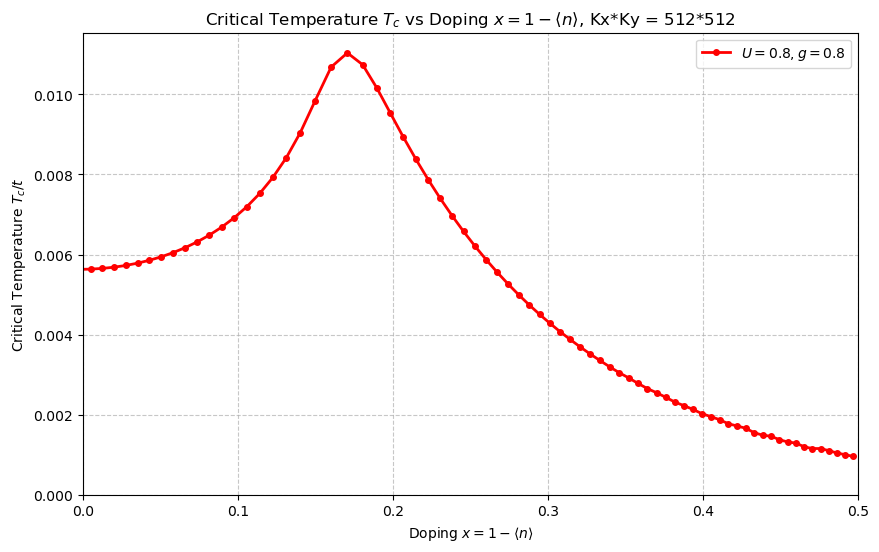

In [78]:
x_final_1 = x_final
Tc_final_1 = Tc_final

plt.figure(figsize=(10, 6))
plt.plot(x_final_1, Tc_final_1, 'ro-', linewidth=2, markersize=4, label=f'$U={U}, g={g}$')
plt.title(f'Critical Temperature $T_c$ vs Doping $x = 1 - \\langle n \\rangle$, Kx*Ky = {Nk}*{Nk}')
plt.xlabel('Doping $x = 1 - \\langle n \\rangle$')
plt.ylabel('Critical Temperature $T_c / t$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.5) # 通常只显示 x=0 到 x=0.5 区域
plt.ylim(bottom=0)
plt.legend()
plt.show() 

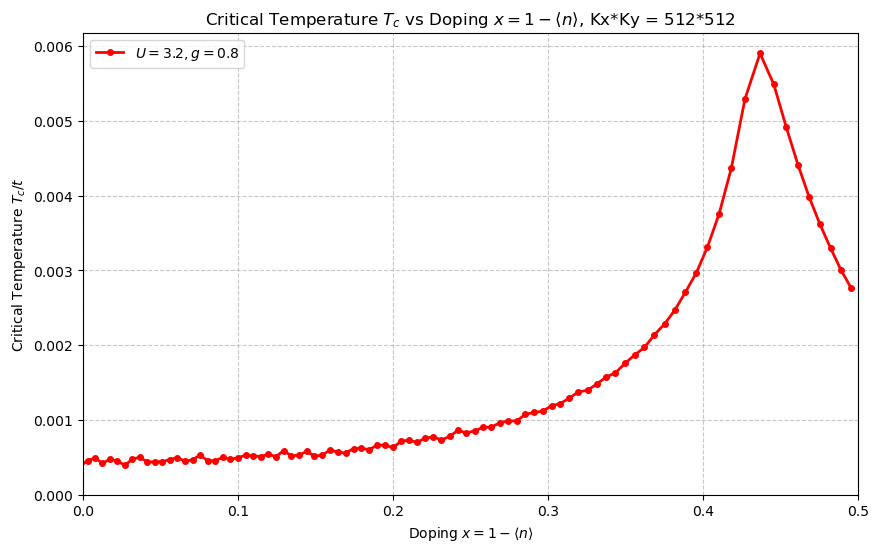

In [75]:
x_final_2 = x_final
Tc_final_2 = Tc_final

plt.figure(figsize=(10, 6))
plt.plot(x_final_2, Tc_final_2, 'ro-', linewidth=2, markersize=4, label=f'$U={U}, g={g}$')
plt.title(f'Critical Temperature $T_c$ vs Doping $x = 1 - \\langle n \\rangle$, Kx*Ky = {Nk}*{Nk}')
plt.xlabel('Doping $x = 1 - \\langle n \\rangle$')
plt.ylabel('Critical Temperature $T_c / t$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.5) # 通常只显示 x=0 到 x=0.5 区域
plt.ylim(bottom=0)
plt.legend()
plt.show() 

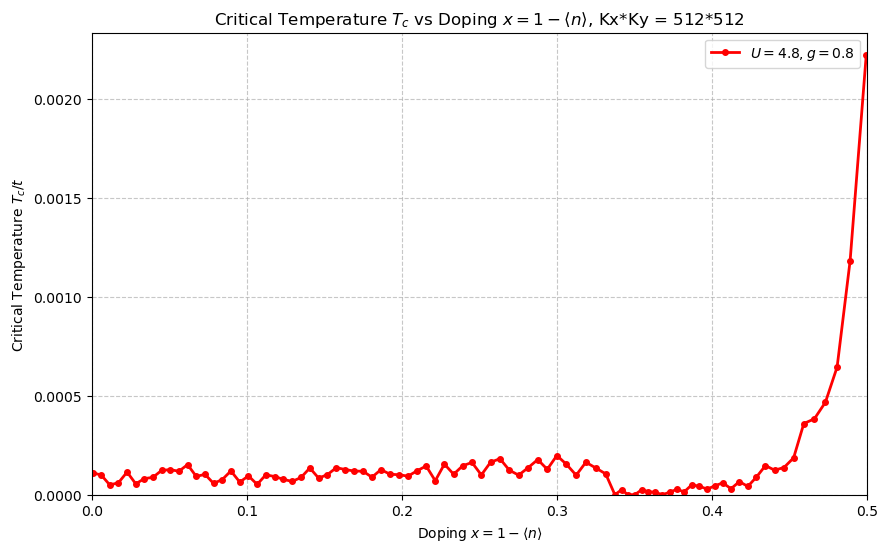

In [71]:
x_final_3 = x_final
Tc_final_3 = Tc_final

plt.figure(figsize=(10, 6))
plt.plot(x_final_3, Tc_final_3, 'ro-', linewidth=2, markersize=4, label=f'$U={U}, g={g}$')
plt.title(f'Critical Temperature $T_c$ vs Doping $x = 1 - \\langle n \\rangle$, Kx*Ky = {Nk}*{Nk}')
plt.xlabel('Doping $x = 1 - \\langle n \\rangle$')
plt.ylabel('Critical Temperature $T_c / t$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.5) # 通常只显示 x=0 到 x=0.5 区域
plt.ylim(bottom=0)
plt.legend()
plt.show() 

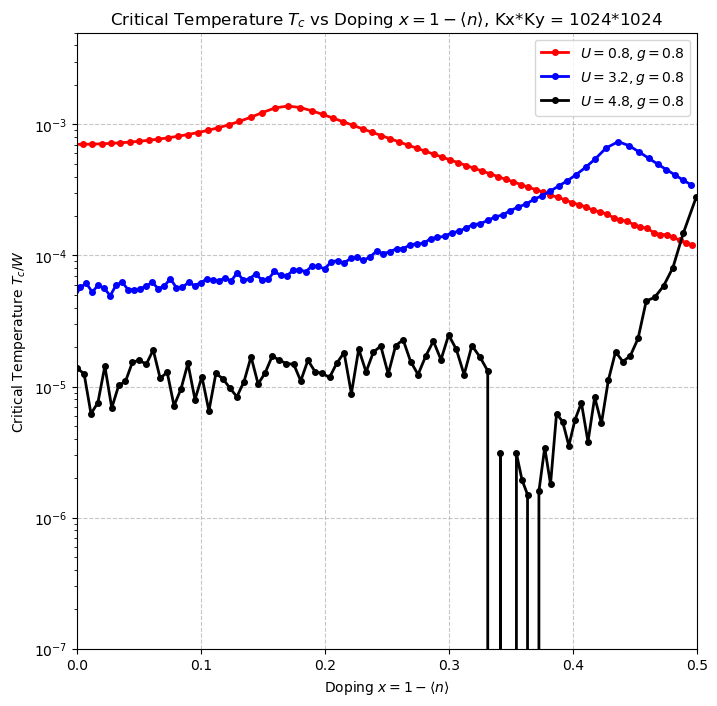

In [ ]:
#Nat. Phys. 16, 1175–1180 (2020) figure 2
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_yscale('log')
plt.plot(x_final_1, Tc_final_1/W, 'ro-', linewidth=2, markersize=4, label=f'$U=0.8, g={g}$')
plt.plot(x_final_2, Tc_final_2/W, 'bo-', linewidth=2, markersize=4, label=f'$U=3.2, g={g}$')
plt.plot(x_final_3, Tc_final_3/W, 'ko-', linewidth=2, markersize=4, label=f'$U=4.8, g={g}$')
plt.title(f'Critical Temperature $T_c$ vs Doping $x = 1 - \\langle n \\rangle$, Kx*Ky = {Nk*2}*{Nk*2}')
plt.xlabel('Doping $x = 1 - \\langle n \\rangle$')
plt.ylabel('Critical Temperature $T_c / W$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.5) # 通常只显示 x=0 到 x=0.5 区域
plt.legend()
plt.ylim(top=5*1e-3)
plt.ylim(bottom=1e-7)
plt.savefig('HK_Tc.png')
plt.show()

dopping_x = -0.023580887698833708 Tc = 0.012849203455017168
dopping_x = -0.018024027834517176 Tc = 0.012846016921085387
dopping_x = -0.012468007683689164 Tc = 0.012844100440658356
dopping_x = -0.006912518456533512 Tc = 0.01284349616976866
dopping_x = -0.0013571801578471376 Tc = 0.01284430916930504
dopping_x = 0.004198374830878482 Tc = 0.012846561924014423
dopping_x = 0.009754534550761251 Tc = 0.01285030476833913
dopping_x = 0.015311708838192883 Tc = 0.012855445485370577
dopping_x = 0.020870233919137893 Tc = 0.012861888392020425
dopping_x = 0.02643048042528695 Tc = 0.012869638307852708
dopping_x = 0.031992776751472496 Tc = 0.012878749641699234
dopping_x = 0.03755748071619469 Tc = 0.012889198970869561
dopping_x = 0.04312500639725636 Tc = 0.012901071789967323
dopping_x = 0.04869575724520325 Tc = 0.012914244419849272
dopping_x = 0.0542701120930521 Tc = 0.012928662666004136
dopping_x = 0.05984845533785421 Tc = 0.012944446895843266
dopping_x = 0.06543113440343051 Tc = 0.012961576463598667
do

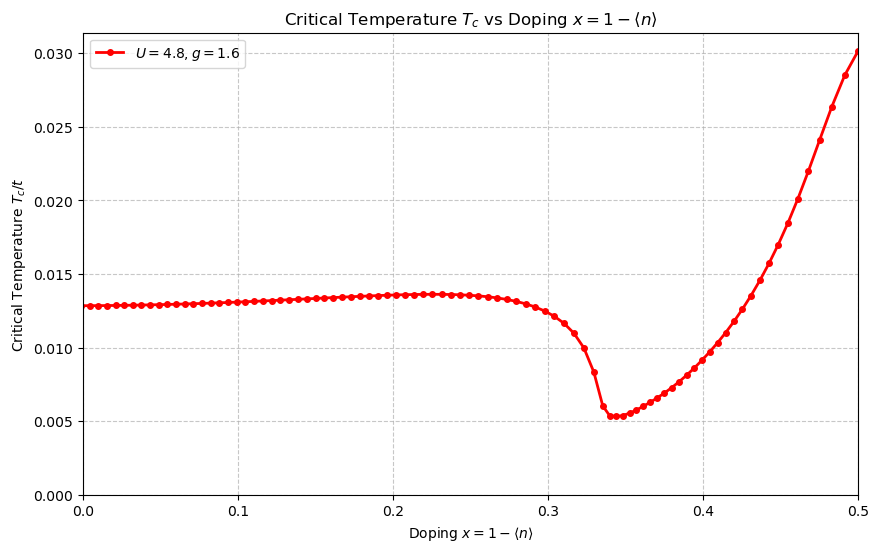

In [ ]:
#HK model Tc vs dopoing large pair coupling g
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time

kB = 1.0
t = 1.0
d = 2.0    #spatial dimension
W = 4*d*t  #band width
#g = 0.1*W  #pair coupling
g = 0.2*W  #pair coupling

#U = 0.1*W
#U = 0.4*W
U = 0.6*W

Nk = 128 *2
kx_list = np.linspace(0, np.pi, Nk, endpoint=False)
ky_list = np.linspace(0, np.pi, Nk, endpoint=False)
KX, KY = np.meshgrid(kx_list, ky_list)
N = Nk * Nk

def average_occupation(mu, T, U, KX, KY, N):
    epsilon = band(KX, KY)
    n_k = occupation_per_spin(epsilon, mu, U, T)
    return 2.0*np.sum(n_k) / N

#mu_list = np.linspace(0.5, -1.5, 100)  #U=0.1*W
#mu_list = np.linspace(1.7, -0.5, 110)  #U=0.1*W
mu_list = np.linspace(2.5, -0.5, 110)  #U=0.1*W

Tc_results = []
Doping_x_results = []

start_time = time.time()
for mu in mu_list:
    Tc = find_Tc(mu, U, g)
    T_threshold = 1e-6
    if Tc > T_threshold:
        avg_n = average_occupation(mu, Tc, U, KX, KY, N)
        doping_x = 1.0 - avg_n
    else:
        avg_n = average_occupation(mu, T_threshold, U, KX, KY, N)
        doping_x = 1.0 - avg_n
    print('dopping_x =', doping_x, 'Tc =', Tc)
    Tc_results.append(Tc)
    Doping_x_results.append(doping_x)

x_plot = np.array(Doping_x_results)
Tc_plot = np.array(Tc_results)

mask_lower = x_plot >= -0.01
mask_upper = x_plot < 0.5
mask_combined = mask_lower & mask_upper

Tc_final = Tc_plot[mask_combined]
x_final = x_plot[mask_combined]

sort_indices = np.argsort(x_final)
x_final = x_final[sort_indices]
Tc_final = Tc_final[sort_indices]

end_time = time.time()
print(end_time-start_time)

plt.figure(figsize=(10, 6))
plt.plot(x_final, Tc_final, 'ro-', linewidth=2, markersize=4, label=f'$U={U}, g={g}$')
plt.title(f'Critical Temperature $T_c$ vs Doping $x = 1 - \\langle n \\rangle$')
plt.xlabel('Doping $x = 1 - \\langle n \\rangle$')
plt.ylabel('Critical Temperature $T_c / t$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 0.5) # 通常只显示 x=0 到 x=0.5 区域
plt.ylim(bottom=0)
plt.legend()
plt.show() 